<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Exercise Set 2 - 2 - Different Activation Functions in a Regression Neural Network

This is a copy of notebook ```nn-regr.ipynb``` for solving the following exercises:

  0. Run all cells.  
   
  1. Replace the sigmoid activation function with the **ReLU** function and observe how the shape of the predicted curve changes. *Revert back* afterwards to the *sigmoid* activation function.
   
  2. **Shift** the simulated data on the **x**-axis by **+50**.  
    2.1. **For the mathematically inclined:**   
    Let $x' := x + 50$. Show or argue that it theoretically does not matter if you shift (use input $x'$) or not (use $x$):  *For any neural net $f(x)$ there is a neural net $f'(x')$ such that $f'(x') = f(x)$*. You may assume that $n=1$.  
    2.2. **Go to ADD YOUR CODE HERE** and follow the instructions. Run all cells. What happens to the goodness of the fit? Do you have an explanation? Tip: Compute the net activations of the first layer manually right before training starts.

### **Answer to 2.1.:**
<img style="float:left" src="../../reparametrize.png" width="200px" />

Let $z_j$ be any particular net activation of the first hidden layer. We omit the superscripts that indicate the layers, here.

$$\begin{align*}
z_j &= \theta_{j,0} + \theta_{j,1} \cdot x\\
&=  \theta_{j,0} + \theta_{j,1} \cdot (x' - 50)\\
&= (\theta_{j,0} - 50 \cdot \theta_{j,1}) + \theta_{j,1} \cdot x'\\
&= \theta'_{j,0} + \theta_{j,1} \cdot x'
\end{align*}
$$

if one defines the bias term for the $j$-th unit of the first hidden layer of $f'$ as $\theta'_{j,0}:=\theta_{j,0} - 50 \cdot \theta_{j,1}$. Therefore, the activations of the first hidden layer are equal in the two networks and the remaining layers can be identical for the two networks to compute identical functions.

## Generate an Artificial Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
def f(x):
    '''A simple one-dimensional function with a few extrema'''
    return np.sin(15 * x) + 9 * x - 9 * x**2

#### Simulate $(x, y)$ pairs as artificial data set

In [3]:
np.random.seed(1)
m = 100 # number of data points (examples)
x = np.linspace(0, 1, m) # equidistant in [0,1] (both boundaries included)
y_theoretical = f(x)     # the points on the curve
# ADD YOUR CODE HERE to shift x by +50, 1 line
x = x + 50
# YOUR CODE ENDS
sigma = 0.1
y = y_theoretical + sigma * np.random.randn(m) # observations have noise (normal with mean 0 and variance sigma^2 = 0.01)

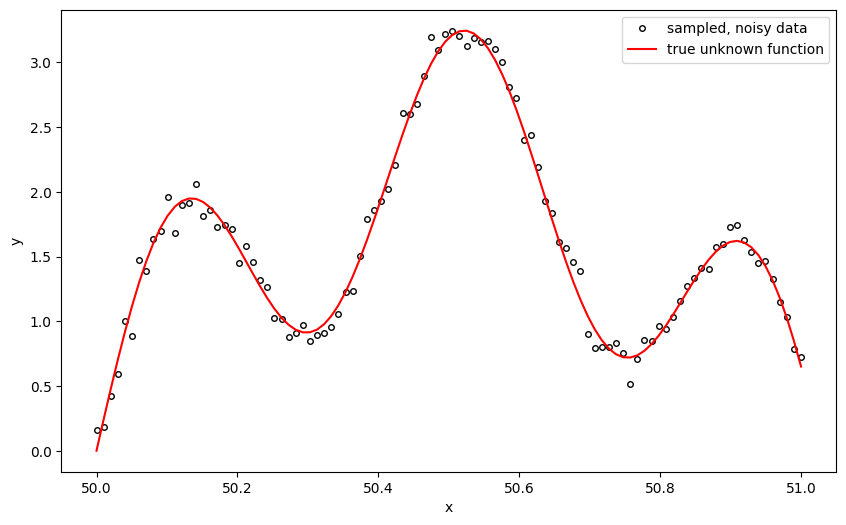

In [4]:
def plot_curve():
    fig, ax = plt.subplots(figsize = (10, 6))
    ax.plot(x, y, 'ko', fillstyle = 'none', markersize = 4, label = "sampled, noisy data") # ko: blac(k) circle
    ax.plot(x, y_theoretical, 'r', label = "true unknown function")
    plt.xlabel("x")
    plt.ylabel("y")
    return ax

ax = plot_curve()
ax.legend();

## Create Neural Network Model  
We will use [```tf.keras```](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras), a high-level approach to neural network design and learning. The NN shall have 2 hidden layers with 8 neurons each. As activation functions we chose the logistic sigmoid function $\sigma$.

<img src="../../nn8-8.png" alt="network architecture" width="500"/>

In [5]:
torch.manual_seed(13032021)  # so we all get the same pseudorandom results

# Many neural networks are a stack of layers, in PyTorch called "Sequential" model
model = nn.Sequential()  # so far the stack is empty, 0 layers

# add neural network layers one by one
# Linear is a fully connected layer, parametrized by a matrix
# of shape (input_features, output_features).
# The first number given in Linear is the number of input features, the second is output features.
# By default bias=True which adds output_features parameters for each layer
# REPLACE THE ACTIVATION FUNCTION HERE with torch.nn.ReLU
model.add_module("layer1", nn.Linear(1, 8))  # input dimension required for first layer
model.add_module("act1", nn.Sigmoid())
model.add_module("layer2", nn.Linear(8, 8))
model.add_module("act2", nn.Sigmoid())
# YOUR CHANGES END HERE
model.add_module("layer3", nn.Linear(8, 1))
model.to(device)  # move model to device (GPU if available)

model.eval()  # ensures consistent behavior for summary/weights
print(model)  # summarizes layers
summary(model, (1,))  # input shape is (batch_size, 1)
# a look under the 'hood' for teaching purposes
Theta = list(model.parameters())  # returns a list of parameter tensors
for i, param in enumerate(Theta):
    print(f"Parameter {i}: {param.shape}\n{param.data}")

Sequential(
  (layer1): Linear(in_features=1, out_features=8, bias=True)
  (act1): Sigmoid()
  (layer2): Linear(in_features=8, out_features=8, bias=True)
  (act2): Sigmoid()
  (layer3): Linear(in_features=8, out_features=1, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]              16
           Sigmoid-2                    [-1, 8]               0
            Linear-3                    [-1, 8]              72
           Sigmoid-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
Total params: 97
Trainable params: 97
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
Paramet

## Explanation, why the training with the x-shift by +50 fails
To see this we will manually compute the **activations of the first layer right after the random initialization** of the model parameters.

In [6]:
Theta0 = Theta[0].cpu().detach().numpy() # weights of the first layer, shape =(1,8)
bias0 = Theta[1].cpu().detach().numpy() # biases of the first layer, shape = (8,) 
print (Theta0.shape, bias0.shape, x.shape)

(8, 1) (8,) (100,)


In [7]:
# compute net activations of first layer
# YOUR CODE HERE to compute the net activations of the first hidden layer, 1 line
z1 = np.matmul(Theta0, x.reshape((1,-1))) + bias0.reshape((-1,1))
# YOUR CODE ENDS
print(z1.shape)

def sigmoid(z):
    """The logistic sigmoid function"""
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(x):
    """ The derivative of sigmoid"""
    return sigmoid(x) * (1-sigmoid(x))


print("z1\n", z1[:,0:5].round(3)) # print the net activations of the first layer for the first example
print("\na1\n", sigmoid(z1[:,0:5])) # print the activations of the first layer for the first 5 examples
print("\nderivatives used in backprop:\n", sigmoid_deriv(z1[:,0:5]))

(8, 100)
z1
 [[-41.651 -41.659 -41.668 -41.676 -41.684]
 [-25.928 -25.933 -25.938 -25.943 -25.949]
 [ -7.877  -7.879  -7.88   -7.881  -7.883]
 [ 14.244  14.247  14.25   14.253  14.256]
 [-28.113 -28.118 -28.124 -28.129 -28.135]
 [ 22.052  22.057  22.061  22.065  22.07 ]
 [ 29.534  29.54   29.546  29.552  29.558]
 [-44.737 -44.746 -44.755 -44.764 -44.772]]

a1
 [[8.15122905e-19 8.08377671e-19 8.01688255e-19 7.95054194e-19
  7.88475031e-19]
 [5.49209676e-12 5.46351141e-12 5.43507483e-12 5.40678627e-12
  5.37864494e-12]
 [3.79204771e-04 3.78649556e-04 3.78095154e-04 3.77541563e-04
  3.76988782e-04]
 [9.99999349e-01 9.99999351e-01 9.99999352e-01 9.99999354e-01
  9.99999356e-01]
 [6.17638342e-13 6.14262427e-13 6.10904963e-13 6.07565852e-13
  6.04244991e-13]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00]
 [3.72325719e-20 3.69047106e-20 3.65797364e-20 3.62576238e-20
  3.59383476e-2

**Observation:** Almost all net activations of the first layer have a large absolute value. For large absolute value the logistic sigmoid function has a derivative very close to 0:

<img src="../../activ-sigma.png" alt="sigmoid function" width="300"/>

Therefore, any small change to any weight of an edge of the first layer that goes into such a unit is very close to 0 or even vanishes numerically.

### Compile the model

In [8]:
# Convert numpy data to torch tensors
x_tensor = torch.tensor(x, dtype=torch.float32).reshape(-1,1).to(device)
y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

### Train the parameters (learning)

In [9]:
num_epochs = 5000
history = []
model.train()
for epoch in range(num_epochs): # takes a few seconds
    optimizer.zero_grad()
    outputs = model(x_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    history.append(loss.item())
    
    # Optionally print every 500 epochs
    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} -- Loss: {loss.item():.6f}")

Epoch 500/5000 -- Loss: 0.603518
Epoch 1000/5000 -- Loss: 0.603518
Epoch 1500/5000 -- Loss: 0.603518
Epoch 2000/5000 -- Loss: 0.603518
Epoch 2500/5000 -- Loss: 0.603518
Epoch 3000/5000 -- Loss: 0.603518
Epoch 3500/5000 -- Loss: 0.603518
Epoch 4000/5000 -- Loss: 0.603518
Epoch 4500/5000 -- Loss: 0.603518
Epoch 5000/5000 -- Loss: 0.603518


### Examine the learning progress

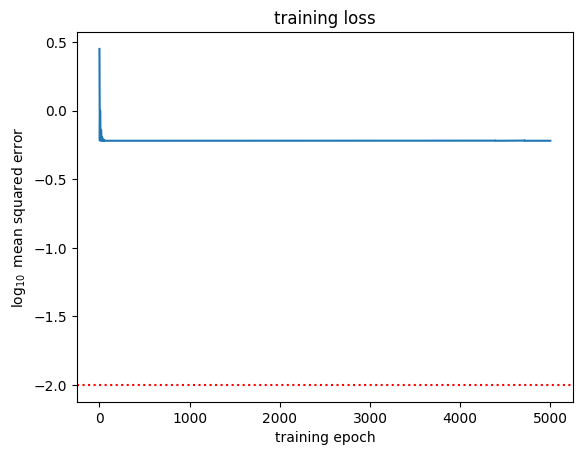

In [10]:
plt.plot(np.log10(history)); # one mse value per epoch
plt.title("training loss")
plt.xlabel("training epoch")
plt.ylabel(r"$\log_{10}$ mean squared error");
plt.axhline(y = np.log10(sigma**2), color = "red", linestyle = ":");

Observe that with our choice for the measurement noise the theoretical optimum for the mean squared error *on new data* is $10^{-2}$ (red dotted line).
### Use the model for predictions

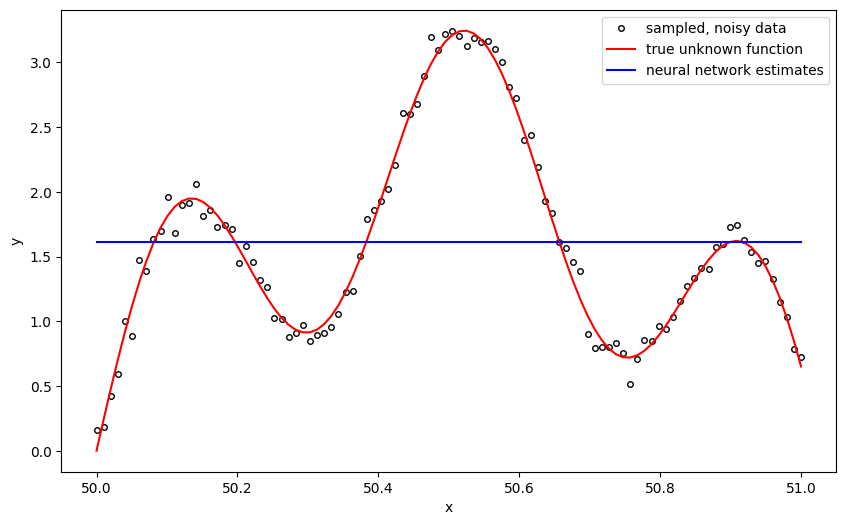

In [11]:
model.eval()
with torch.no_grad():
    y_pred = model(x_tensor).cpu().numpy().flatten()
    
ax = plot_curve()
ax.plot(x, y_pred, 'b', label="neural network estimates")
ax.legend();